In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Load Data
raw_data = load_dataset("lukebarousse/data_jobs")
df = raw_data['train'].to_pandas()

# Cleanup data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

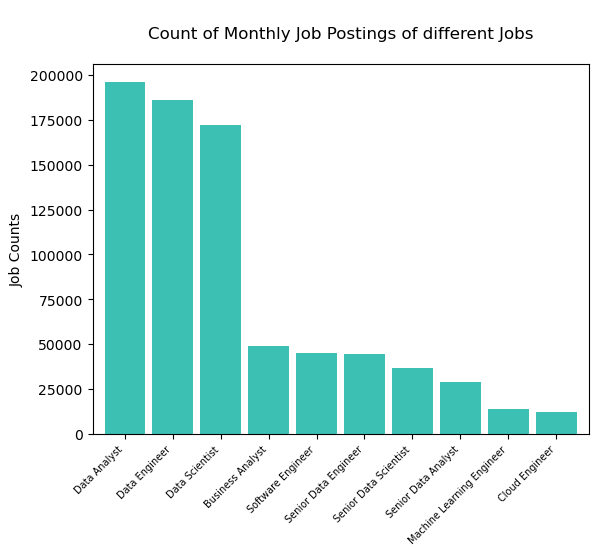

In [2]:
# Using Pandas DataFrame/Series.plot() function which uses Matplotlib.pyplot under the hood to plot. 
# We use series.plot(kind = 'bar'), X and Y labels are automatically detected and labelled

####### FOR SERIES #########

job_counts = df['job_title_short'].value_counts() # It's a Series type object
job_counts.plot(kind = 'bar', width = 0.85, color = '#3dc0b4')
plt.title("\nCount of Monthly Job Postings of different Jobs\n")
plt.ylabel("Job Counts")
plt.xlabel("")
plt.xticks(rotation = 45, ha = "right", fontsize = 7)
plt.show()

<Axes: xlabel='job_posted_date'>

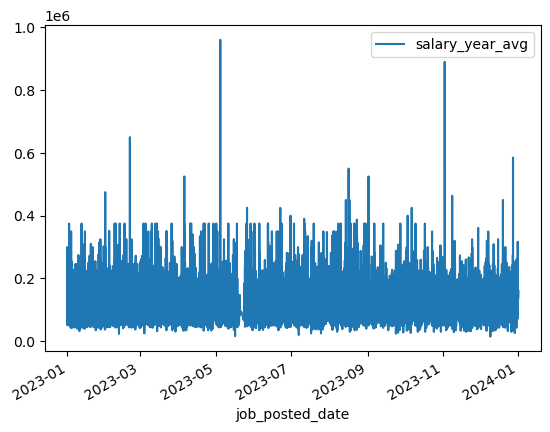

In [3]:
### FOR DATAFRAMES ###

# Remove all the Rows with NaN values for salary_year_avg
df.dropna(subset = ['salary_year_avg'], inplace=True)
df.sort_values(by = 'job_posted_date', inplace=True)


# Y-axis are the Column Names we provide in a List of column names from the DataFrame, X-Axis is the single column
# with respect to which are plotting the Y-axis values

# Plot how Yearly and Hourly Avg Salaries change w.r.t Job Posted Date
df.plot(x = 'job_posted_date', y = ['salary_year_avg'], kind = 'line')

                           mean
job_posted_month               
1                 123007.422072
2                 122913.927237
3                 122947.810047
4                 121856.551050
5                 123656.747729
6                 124321.135360
7                 123470.572994
8                 125819.429100
9                 125222.984594
10                124606.653605
11                119817.184014
12                120199.423414
job_posted_month
1     123007.422072
2     122913.927237
3     122947.810047
4     121856.551050
5     123656.747729
6     124321.135360
7     123470.572994
8     125819.429100
9     125222.984594
10    124606.653605
11    119817.184014
12    120199.423414
Name: salary_year_avg, dtype: float64


Text(0, 0.5, 'Yearly Average Salary for the month')

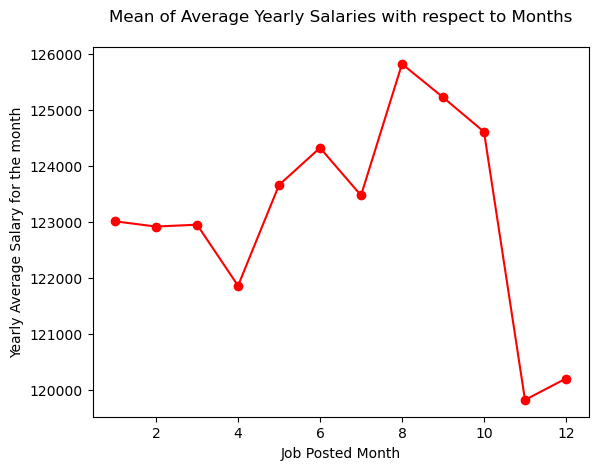

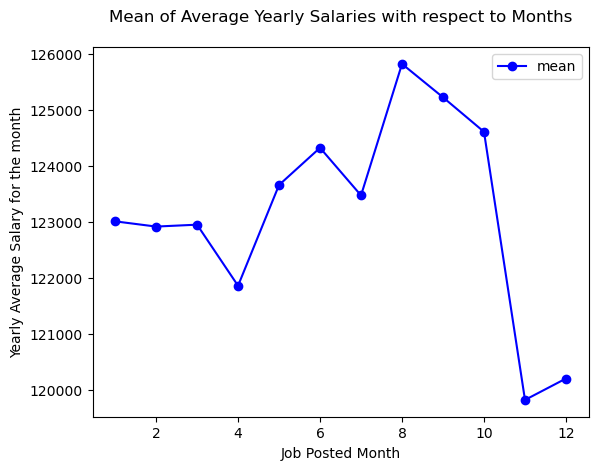

In [24]:
df['job_posted_month'] = df['job_posted_date'].dt.month

months_count = df.value_counts('job_posted_month')
# print(months_count)

# Rule of Thumb: If a word is sitting slightly lower than the other headers in your printout, it's an Index. If it's a "named" column, it's on the same level as the other headers.

avgYearlyAvgSalaries_DF = df.groupby(by = 'job_posted_month')['salary_year_avg'].agg(['mean']) # Gives a Dataframe -> job_posted_month sits slightly lower than the mean column --> So job_posted_moonth is the index, No need of x = __

avgYearlyAvgSalaries_SERIES = df.groupby(by = 'job_posted_month')['salary_year_avg'].mean() # Gives a Series, No column name for mean, only the index column is named job_posted_month

print(avgYearlyAvgSalaries_DF)
print(avgYearlyAvgSalaries_SERIES)

avgYearlyAvgSalaries_SERIES.plot(y = ['mean'], kind = "line", marker = "o", color = "red") # X not allowed for Series
plt.xlabel("Job Posted Month")
plt.ylabel("Yearly Average Salary for the month")
plt.title("Mean of Average Yearly Salaries with respect to Months\n")

avgYearlyAvgSalaries_DF.plot(y = ['mean'], kind = "line", marker = "o", color = "blue") # X not allowed here as well as the Dataframe sorta behaves like a series with the values of 1st col - job_posted_month as the X values.
plt.title("Mean of Average Yearly Salaries with respect to Months\n")
plt.xlabel("Job Posted Month")
plt.ylabel("Yearly Average Salary for the month")